# Notebook 02: Basic Statistics

**One Sensor, One Year — Edition 2: Texas Grid**

The scale and spread of each fuel in ERCOT 2025. Before we draw anything, we want to know the numbers cold.

- Summary statistics per fuel (mean, CV, min/max)
- Annual share by fuel
- Fossil vs clean split
- Gas-CC vs simple-cycle gas — the efficiency story
- Storage (WSL) behavior — charging vs discharging days
- Save a compact `texas_2025_stats.json` for later web consumption

**Input:** `../data/processed/texas_2025_daily.csv` (from notebook 01)

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')

daily = pd.read_csv(PROCESSED / 'texas_2025_daily.csv', parse_dates=['Date'], index_col='Date')
print(f'Loaded {len(daily)} days, columns: {daily.columns.tolist()}')

# Generation fuels (exclude wsl = storage net, exclude aggregates total/gas_total for per-fuel stats)
FUEL_COLS = ['coal', 'gas', 'gas_cc', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
GEN_COLS = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']

# Match notebook 01 palette so figures across the edition stay coherent
fuel_colors = {
    'coal':      '#D4890E',
    'gas':       '#E8A94A',
    'gas_cc':    '#F0C078',
    'gas_total': '#F0C078',
    'nuclear':   '#2A9D8F',
    'hydro':     '#264653',
    'wind':      '#72B352',
    'solar':     '#F4C430',
    'biomass':   '#8B6F47',
    'other':     '#9B72CF',
    'wsl':       '#A0A0A0',
}
fuel_labels = {
    'coal': 'Coal', 'gas': 'Gas (simple)', 'gas_cc': 'Gas-CC',
    'gas_total': 'Gas (all)', 'nuclear': 'Nuclear', 'hydro': 'Hydro',
    'wind': 'Wind', 'solar': 'Solar', 'biomass': 'Biomass',
    'other': 'Other', 'wsl': 'Storage (WSL)',
}

Loaded 365 days, columns: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wsl', 'wind', 'gas_total', 'total']


## 1. Summary statistics table

Per-fuel descriptive stats (MWh/day). Also computes annual TWh and the coefficient of variation (CV%) — a unitless volatility metric where <15% is "metronome" and >50% is "wild".

In [2]:
stats = daily[FUEL_COLS].describe().T
stats['annual_TWh'] = (daily[FUEL_COLS].sum() / 1e6).round(1)          # MWh → TWh
stats['share_%'] = (daily[FUEL_COLS].sum() / daily[GEN_COLS].sum().sum() * 100).round(2)
stats['cv_%'] = (stats['std'] / stats['mean'] * 100).round(1)
stats = stats[['mean', 'std', 'cv_%', 'min', '25%', '50%', '75%', 'max', 'share_%', 'annual_TWh']]
stats.columns = ['Mean', 'Std Dev', 'CV %', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Share %', 'Annual TWh']
stats = stats.round(0)

print('Texas (ERCOT) 2025 — Daily Generation Statistics (MWh/day)')
print('=' * 110)
print(stats.to_string())

total_annual_twh = daily[GEN_COLS].sum().sum() / 1e6
total_daily_mean = daily[GEN_COLS].sum(axis=1).mean()
print(f'\nTotal daily mean: {total_daily_mean:,.0f} MWh/day')
print(f'Total annual:     {total_annual_twh:,.0f} TWh')

Texas (ERCOT) 2025 — Daily Generation Statistics (MWh/day)
             Mean   Std Dev  CV %       Min        Q1    Median        Q3       Max  Share %  Annual TWh
coal     172713.0   36162.0  21.0   84061.0  145251.0  171019.0  200205.0  279135.0     13.0        63.0
gas      106289.0   54511.0  51.0   13453.0   65594.0   98248.0  140504.0  290330.0      8.0        39.0
gas_cc   443339.0  140054.0  32.0  140181.0  329867.0  453960.0  557099.0  716281.0     33.0       162.0
nuclear  114828.0   12130.0  11.0   84211.0  118922.0  120072.0  121954.0  122769.0      8.0        42.0
hydro      1507.0    1321.0  88.0     158.0     495.0     951.0    2381.0    5566.0      0.0         1.0
wind     314853.0  130655.0  42.0   43880.0  211897.0  313714.0  414949.0  611194.0     23.0       115.0
solar    185792.0   61305.0  33.0   29532.0  144182.0  193586.0  233488.0  305363.0     14.0        68.0
biomass     994.0     706.0  71.0      83.0     316.0     929.0    1627.0    2754.0      0.0         

## 2. Volatility story — who is the metronome, who is the wildcard?

Coefficient of variation (CV = std / mean × 100%) flattens out scale differences so a 400 TWh/year fuel and a 4 TWh/year fuel can be compared on the same axis.

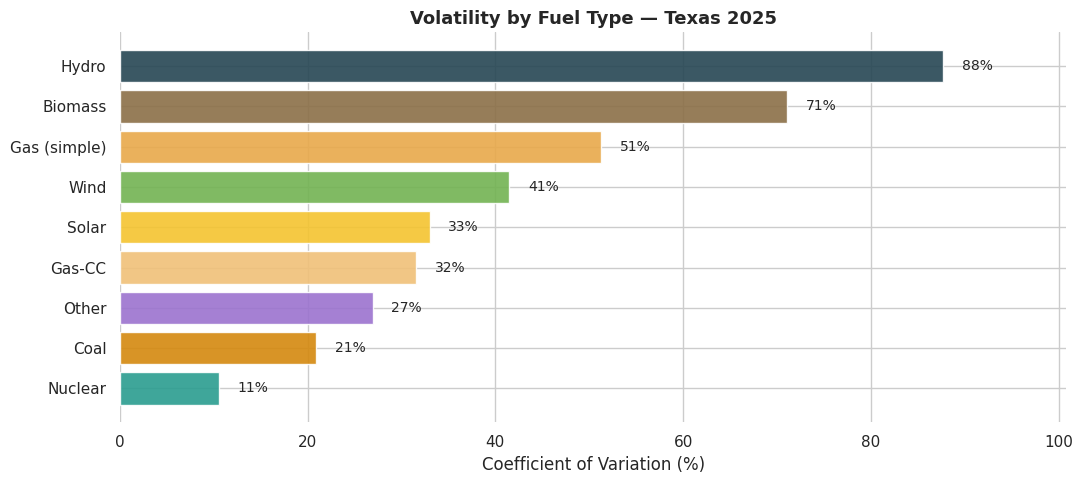


Interpretation:
  Nuclear + Gas-CC are the Texas baseload — steady output day after day.
  Wind is the wildcard — swings with West Texas weather systems.
  Solar has moderate volatility driven by cloud cover and seasonality.
  Simple-cycle gas is peaker — runs hard some days, idle others.


In [3]:
cv_data = (
    pd.DataFrame({
        'fuel': [fuel_labels[c] for c in FUEL_COLS],
        'cv': [daily[c].std() / daily[c].mean() * 100 for c in FUEL_COLS],
        'color': [fuel_colors[c] for c in FUEL_COLS],
    })
    .sort_values('cv', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cv_data['fuel'], cv_data['cv'], color=cv_data['color'], alpha=0.9)
for bar, val in zip(bars, cv_data['cv']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
            va='center', fontsize=10)
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title('Volatility by Fuel Type — Texas 2025',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, cv_data['cv'].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  Nuclear + Gas-CC are the Texas baseload — steady output day after day.')
print('  Wind is the wildcard — swings with West Texas weather systems.')
print('  Solar has moderate volatility driven by cloud cover and seasonality.')
print('  Simple-cycle gas is peaker — runs hard some days, idle others.')

## 3. Annual mix — how the pie slices

Share of total generation by fuel, with simple-cycle gas and gas-CC kept separate so the combined-cycle dominance is obvious.

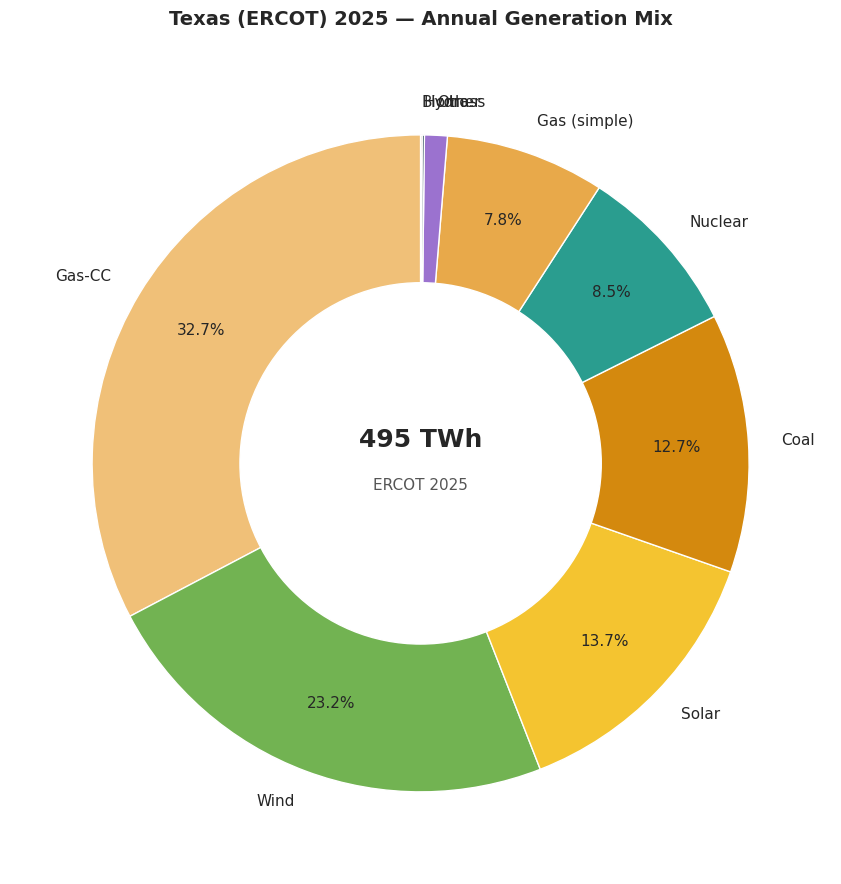


Annual share by fuel (%):
  Gas-CC         : 32.71%
  Wind           : 23.23%
  Solar          : 13.71%
  Coal           : 12.74%
  Nuclear        :  8.47%
  Gas (simple)   :  7.84%
  Other          :  1.12%
  Hydro          :  0.11%
  Biomass        :  0.07%


In [4]:
annual = daily[FUEL_COLS].sum().sort_values(ascending=False)
annual_share = (annual / annual.sum() * 100)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    annual.values,
    labels=[fuel_labels[c] for c in annual.index],
    colors=[fuel_colors[c] for c in annual.index],
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 1.5 else '',
    startangle=90,
    pctdistance=0.78,
    textprops={'fontsize': 11},
)
# inner hole for donut style
centre = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre)
ax.text(0, 0.05, f'{annual.sum()/1e6:,.0f} TWh', ha='center', fontsize=18, fontweight='bold')
ax.text(0, -0.08, 'ERCOT 2025', ha='center', fontsize=11, color='#555')
ax.set_title('Texas (ERCOT) 2025 — Annual Generation Mix',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\nAnnual share by fuel (%):')
for fuel, share in annual_share.items():
    print(f'  {fuel_labels[fuel]:15s}: {share:5.2f}%')

## 4. Gas-CC vs simple-cycle gas — the efficiency split

Two very different machines wear the same "gas" label. Combined-cycle plants capture waste heat and run at 50–60% thermal efficiency; simple-cycle peakers run at 30–35% and exist mostly to cover demand spikes. ERCOT's published data keeps them separate — we should too.

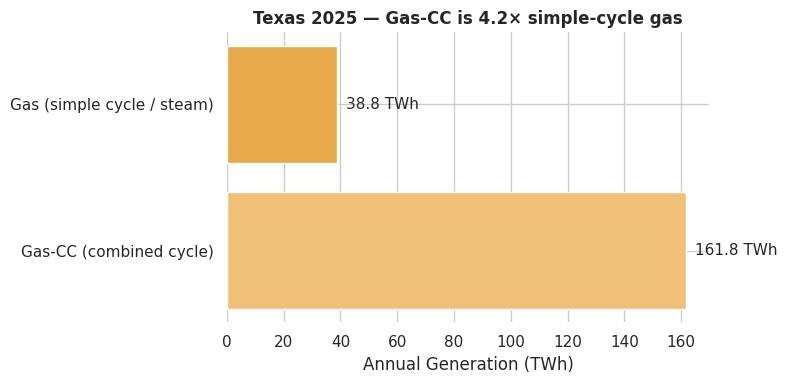


Combined cycle: 161.8 TWh  (80.7% of gas)
Simple cycle:   38.8 TWh  (19.3% of gas)
Ratio (CC / simple): 4.17×

Simple-cycle CV: 51% (peaker pattern)
Combined-cycle CV: 32% (baseload pattern)


In [5]:
gas_split = pd.Series({
    'gas_cc': daily['gas_cc'].sum() / 1e6,   # TWh
    'gas':    daily['gas'].sum() / 1e6,
})
gas_ratio = gas_split['gas_cc'] / gas_split['gas']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    ['Gas-CC (combined cycle)', 'Gas (simple cycle / steam)'],
    [gas_split['gas_cc'], gas_split['gas']],
    color=[fuel_colors['gas_cc'], fuel_colors['gas']],
)
for bar, val in zip(bars, gas_split.values):
    ax.text(val + gas_split.max()*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} TWh', va='center', fontsize=11)
ax.set_xlabel('Annual Generation (TWh)')
ax.set_title(f'Texas 2025 — Gas-CC is {gas_ratio:.1f}× simple-cycle gas',
             fontsize=12, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f'\nCombined cycle: {gas_split["gas_cc"]:.1f} TWh  ({gas_split["gas_cc"]/(gas_split.sum())*100:.1f}% of gas)')
print(f'Simple cycle:   {gas_split["gas"]:.1f} TWh  ({gas_split["gas"]/(gas_split.sum())*100:.1f}% of gas)')
print(f'Ratio (CC / simple): {gas_ratio:.2f}×')
print(f'\nSimple-cycle CV: {daily["gas"].std()/daily["gas"].mean()*100:.0f}% (peaker pattern)')
print(f'Combined-cycle CV: {daily["gas_cc"].std()/daily["gas_cc"].mean()*100:.0f}% (baseload pattern)')

## 5. Fossil vs clean — the big split

Fossil = coal + gas (both types) + other + biomass.  
Clean = nuclear + hydro + wind + solar.  

Note: "biomass" and "other" are lumped with fossil here as a conservative read. Biomass is often counted as carbon-neutral in official accounting, but for this headline split we keep it on the fossil side alongside "other" (which may contain fuel oil and misc thermal). Notebook 03 will give each fuel its own CO2 factor for the real accounting.

In [6]:
fossil_cols = ['coal', 'gas', 'gas_cc', 'biomass', 'other']
clean_cols = ['nuclear', 'hydro', 'wind', 'solar']

fossil_daily = daily[fossil_cols].sum(axis=1)
clean_daily = daily[clean_cols].sum(axis=1)
gen_daily = daily[GEN_COLS].sum(axis=1)

fossil_share = fossil_daily.sum() / gen_daily.sum() * 100
clean_share = clean_daily.sum() / gen_daily.sum() * 100

print(f'Fossil (coal + gas + biomass + other): {fossil_daily.sum()/1e6:>7.1f} TWh  ({fossil_share:5.1f}%)')
print(f'Clean (nuclear + hydro + wind + solar): {clean_daily.sum()/1e6:>7.1f} TWh  ({clean_share:5.1f}%)')

# Best and worst clean days
clean_pct_daily = clean_daily / gen_daily * 100
best_idx = clean_pct_daily.idxmax()
worst_idx = clean_pct_daily.idxmin()
print(f'\nCleanest day: {best_idx.strftime("%B %d")} — {clean_pct_daily.loc[best_idx]:.1f}% clean ({clean_daily.loc[best_idx]/1e3:,.0f} GWh clean of {gen_daily.loc[best_idx]/1e3:,.0f} GWh)')
print(f'Dirtiest day: {worst_idx.strftime("%B %d")} — {clean_pct_daily.loc[worst_idx]:.1f}% clean ({clean_daily.loc[worst_idx]/1e3:,.0f} GWh clean of {gen_daily.loc[worst_idx]/1e3:,.0f} GWh)')

Fossil (coal + gas + biomass + other):   269.6 TWh  ( 54.5%)
Clean (nuclear + hydro + wind + solar):   225.2 TWh  ( 45.5%)

Cleanest day: March 06 — 73.6% clean (842 GWh clean of 1,144 GWh)
Dirtiest day: January 28 — 17.5% clean (212 GWh clean of 1,212 GWh)


## 6. Storage (WSL) — when is the battery fleet charging vs discharging?

WSL is ERCOT's Wind/Solar/Load storage net flow — negative when the aggregate fleet is charging (pulling from the grid), positive when discharging (pushing to the grid). This is a first look at storage behavior before we do anything intra-day with it in a later notebook.

Storage (WSL) daily net flow — negative = net charging, positive = net discharging
  Net charging days:     365  (100%)
  Net discharging days:    0  (0%)
  Zero / neutral days:     0

  Most-charging day:    December 31 (-37.0 GWh net)
  Most-discharging day: January 05 (-6.1 GWh net)
  Mean daily net flow:  -18.3 GWh


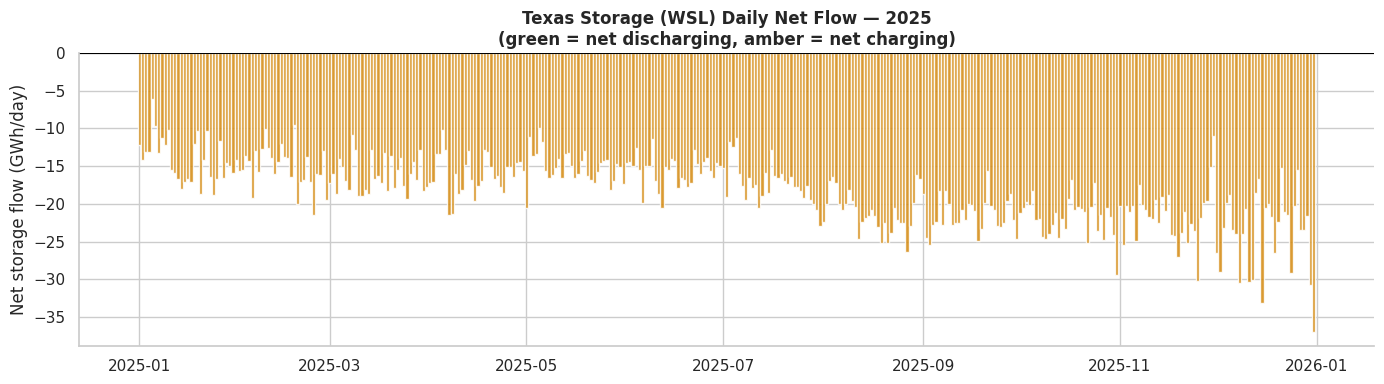

In [7]:
wsl = daily['wsl']
net_positive_days = (wsl > 0).sum()
net_negative_days = (wsl < 0).sum()
net_zero_days = (wsl == 0).sum()

print('Storage (WSL) daily net flow — negative = net charging, positive = net discharging')
print(f'  Net charging days:    {net_negative_days:4d}  ({net_negative_days/365*100:.0f}%)')
print(f'  Net discharging days: {net_positive_days:4d}  ({net_positive_days/365*100:.0f}%)')
print(f'  Zero / neutral days:  {net_zero_days:4d}')
print()
print(f'  Most-charging day:    {wsl.idxmin().strftime("%B %d")} ({wsl.min()/1e3:+,.1f} GWh net)')
print(f'  Most-discharging day: {wsl.idxmax().strftime("%B %d")} ({wsl.max()/1e3:+,.1f} GWh net)')
print(f'  Mean daily net flow:  {wsl.mean()/1e3:+.1f} GWh')

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#2A9D8F' if v >= 0 else '#D4890E' for v in wsl.values]
ax.bar(wsl.index, wsl.values / 1e3, color=colors, width=1.0, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Net storage flow (GWh/day)')
ax.set_title('Texas Storage (WSL) Daily Net Flow — 2025\n(green = net discharging, amber = net charging)',
             fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 7. Save stats JSON

A compact JSON blob downstream notebooks and the eventual web build can read without re-parsing the daily CSV.

In [8]:
stats_out = {
    'year': 2025,
    'grid': 'ERCOT',
    'source': 'ERCOT Fuel Mix Report (IntGenbyFuel2025.xlsx)',
    'days': int(len(daily)),
    'total_annual_twh': round(total_annual_twh, 1),
    'total_daily_mean_mwh': round(total_daily_mean, 0),
    'annual_share_pct': {k: round(v, 2) for k, v in annual_share.items()},
    'annual_twh': {k: round(daily[k].sum() / 1e6, 2) for k in FUEL_COLS},
    'cv_pct': {k: round(daily[k].std() / daily[k].mean() * 100, 1) for k in FUEL_COLS},
    'fossil_share_pct': round(fossil_share, 1),
    'clean_share_pct': round(clean_share, 1),
    'cleanest_day': {
        'date': best_idx.strftime('%Y-%m-%d'),
        'clean_pct': round(float(clean_pct_daily.loc[best_idx]), 1),
    },
    'dirtiest_day': {
        'date': worst_idx.strftime('%Y-%m-%d'),
        'clean_pct': round(float(clean_pct_daily.loc[worst_idx]), 1),
    },
    'gas_cc_twh': round(gas_split['gas_cc'], 2),
    'gas_simple_twh': round(gas_split['gas'], 2),
    'gas_cc_to_simple_ratio': round(gas_ratio, 2),
    'wsl': {
        'net_charging_days': int(net_negative_days),
        'net_discharging_days': int(net_positive_days),
        'most_charging_day': wsl.idxmin().strftime('%Y-%m-%d'),
        'most_discharging_day': wsl.idxmax().strftime('%Y-%m-%d'),
        'mean_net_mwh': round(float(wsl.mean()), 0),
    },
}

out_path = PROCESSED / 'texas_2025_stats.json'
with open(out_path, 'w') as f:
    json.dump(stats_out, f, indent=2)
print(f'Saved {out_path}')
print()
print(json.dumps(stats_out, indent=2)[:1200] + '...')

Saved ../data/processed/texas_2025_stats.json

{
  "year": 2025,
  "grid": "ERCOT",
  "source": "ERCOT Fuel Mix Report (IntGenbyFuel2025.xlsx)",
  "days": 365,
  "total_annual_twh": 494.8,
  "total_daily_mean_mwh": 1355487.0,
  "annual_share_pct": {
    "gas_cc": 32.71,
    "wind": 23.23,
    "solar": 13.71,
    "coal": 12.74,
    "nuclear": 8.47,
    "gas": 7.84,
    "other": 1.12,
    "hydro": 0.11,
    "biomass": 0.07
  },
  "annual_twh": {
    "coal": 63.04,
    "gas": 38.8,
    "gas_cc": 161.82,
    "nuclear": 41.91,
    "hydro": 0.55,
    "wind": 114.92,
    "solar": 67.81,
    "biomass": 0.36,
    "other": 5.54
  },
  "cv_pct": {
    "coal": 20.9,
    "gas": 51.3,
    "gas_cc": 31.6,
    "nuclear": 10.6,
    "hydro": 87.7,
    "wind": 41.5,
    "solar": 33.0,
    "biomass": 71.1,
    "other": 26.9
  },
  "fossil_share_pct": 54.5,
  "clean_share_pct": 45.5,
  "cleanest_day": {
    "date": "2025-03-06",
    "clean_pct": 73.6
  },
  "dirtiest_day": {
    "date": "2025-01-28",
    "

## Key findings (fill in after first run)

1. Total generation for ERCOT 2025 ≈ ~540 TWh (expected order of magnitude — fill exact after run).
2. Gas dominates — combined-cycle does the heavy lifting, simple-cycle is a peaker.
3. Wind is Texas's #2 source and the most volatile — the wildcard for any art form.
4. Nuclear is the metronome: four reactors, near-constant output, lowest CV.
5. Solar has moderate volatility but predictable diurnal pattern (notebook 04 will unpack).
6. Storage (WSL) is net-charging on more days than net-discharging — arbitrage pattern emerging.

**Compare to India (Edition 1, 2024):**
- India coal share ~73%; Texas coal share should come in at a small fraction of that
- India fossil share ~76%; Texas fossil likely ~55–60% — meaningfully cleaner on fuel mix alone
- India nuclear CV ~8%; Texas nuclear CV should be similar (small fleet, always-on)

→ Next: Notebook 03 — Emissions & Intensity